/var/folders/rs/gjz_3dy577x99nn5zbg495sh0000gn/T/ipykernel_14444/67036589.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NB_label", y="Areas", data=df, palette="Set2", showfliers=False)


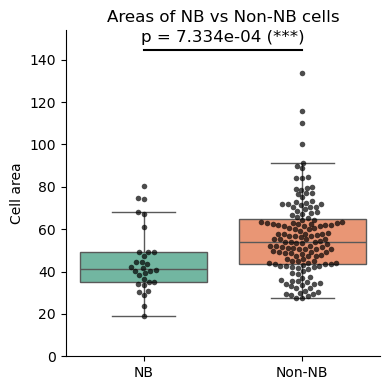

            mean  median     std    n
NB_label                             
NB        44.764  41.192  15.283   30
Non-NB    56.192  54.129  17.873  144


In [1]:
# Script that plots pre-transcription apical areas of presumptive NBs and NCs shown in Figure 3

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load dataset
df = pd.read_csv("AreasInPreSignallingWindows.csv")   # replace with your actual file name

# Convert NB column to labels
df['NB_label'] = df['Neuroblast'].map({1: "NB", 0: "Non-NB"})

# Split into groups
nb_areas = df.loc[df['NB_label'] == "NB", "Areas"]
non_nb_areas = df.loc[df['NB_label'] == "Non-NB", "Areas"]

# Perform t-test (Welch’s by default)
t_stat, p_val = ttest_ind(nb_areas, non_nb_areas, equal_var=False)

# Plot
plt.figure(figsize=(4, 4))
sns.boxplot(x="NB_label", y="Areas", data=df, palette="Set2", showfliers=False)
sns.swarmplot(x="NB_label", y="Areas", data=df, color="black", alpha=0.7, size=4)

plt.title("Areas of NB vs Non-NB cells")
plt.xlabel("")
plt.ylabel("Cell area")

# Add annotation with p-value
ymax = df["Areas"].max()
y_offset = ymax * 0.1   # 10% of range
ypos = ymax + y_offset

if p_val < 0.001:
    significance = "***"
elif p_val < 0.01:
    significance = "**"
elif p_val < 0.05:
    significance = "*"
else:
    significance = "n.s."

plt.text(0.5, ypos, f"p = {p_val:.3e} ({significance})", 
         ha='center', va='bottom', fontsize=12)

# Add connecting line
plt.plot([0, 1], [ypos - y_offset*0.2, ypos - y_offset*0.2], color="black")

# Force y-axis to start from 0
plt.ylim(0, ypos + y_offset * 0.5)

# Remove top and right spines (no square)
sns.despine()

plt.tight_layout()
plt.savefig("areas_nb_vs_nonNB.pdf")
plt.show()

# Compute summary statistics
summary_stats = (
    df.groupby("NB_label")["Areas"]
      .agg(mean="mean",median="median", std="std", n="count")
      .round(3)
)

print(summary_stats)

# Save to Excel
summary_stats.to_excel("areas_NB_vs_NonNB_summary_stats.xlsx")